In [ ]:
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker

import sys
import os

sys.path.append(os.path.abspath(".."))
from utils.generic import table_to_gdf
from utils.rsei_utils import (
    load_rsei_flowlines,
    load_tabular_water_microdata,
    get_source_facilities,
)
from utils.plot_style import apply_plot_style

apply_plot_style()

In [ ]:
datadir = "/projects/standard/lenkne/oboiko/EJ/data/"
huc12 = gpd.read_file(datadir + "aoi_huc12_boundaries.gpkg")
years = range(2008, 2023)
universe = "core01"

ERROR 1: PROJ: proj_create_from_database: Open of /users/2/oboiko/.conda/envs/geo/share/proj failed


In [ ]:
facilities = pd.read_csv(datadir + "source_facilities.csv")
facilities = table_to_gdf(facilities, x="Longitude", y="Latitude")

In [ ]:
flowlines = []
for site in ["Onsite", "Offsite"]:
    for year in range(2008, 2023):
        flowlines.append(
            load_rsei_flowlines(
                site=site, year=year, selection_aoi=huc12, universe=universe
            )
        )
flowlines = pd.concat(flowlines)
flowlines = flowlines.drop_duplicates(keep="first")

In [ ]:
# state outline for context
us_states_gdf = gpd.read_file(
    f"zip://{datadir}/cb_2018_us_state_20m.zip/cb_2018_us_state_20m.shp"
)

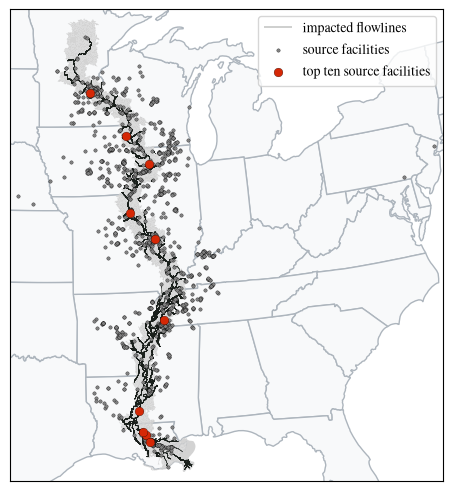

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.8), layout="constrained")

target_crs = huc12.crs

us_states_gdf.to_crs(target_crs).plot(
    ax=ax, edgecolor="#adb5bd", facecolor="#f8f9fa", linewidth=1.0
)
huc12.plot(ax=ax, facecolor="lightgrey")
flowlines.to_crs(target_crs).plot(
    ax=ax,
    color="#1a201c",
    linewidth=0.3,
    zorder=1,
    label="impacted flowlines",
    joinstyle="round",
    capstyle="round",
)
facilities.to_crs(target_crs).plot(
    ax=ax,
    facecolor="grey",
    edgecolor="black",
    linewidth=0.2,
    markersize=6,
    label=f"source facilities",
    zorder=2,
)
# Plot top 10 facilities
facilities.head(10).to_crs(target_crs).plot(
    ax=ax,
    facecolor="#d52806",
    edgecolor="black",
    linewidth=0.2,
    markersize=40,
    zorder=2,
    label="top ten source facilities",
)
# Additional formatting
ax.set_xticks([])
ax.set_yticks([])
# Get bounds for
bounds1 = huc12.total_bounds  # [minx, miny, maxx, maxy]
bounds2 = facilities.to_crs(huc12.crs).total_bounds
# Calculate the combined extremes
minx = min(bounds1[0], bounds2[0])
miny = min(bounds1[1], bounds2[1])
maxx = max(bounds1[2], bounds2[2])
maxy = max(bounds1[3], bounds2[3])
# Apply to your axis
x_margin = (maxx - minx) * 0.02
y_margin = (maxy - miny) * 0.02
ax.set_xlim(minx - x_margin, maxx + x_margin)
ax.set_ylim(miny - y_margin, maxy + y_margin)
ax.legend()

plt.show()

# fig.savefig(f"figures/rsei_source_facilities.pdf")
fig.savefig(f"../figures/Figure S6.pdf")